# BIU DRL Ex03 — Fitness RL: LSTM + REINFORCE + A2C
**Course:** Deep Reinforcement Learning — Dr. Yoram Segal, Bar-Ilan University

This notebook implements all 6 parts of the assignment end-to-end.

## Setup

In [1]:
# Install the package (when running in Colab)
# !pip install -q git+https://github.com/hodayakashh/biu-fitness-training-ex03.git

import os
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# Run from the project root so the relative config/, data/, results/ paths resolve
# whether this notebook is launched from the repo root or from notebooks/.
if not Path('config/setup.json').exists() and Path('../config/setup.json').exists():
    os.chdir('..')
assert Path('config/setup.json').exists(), 'Run from the project root (config/ not found).'

from fitness_rl import FitnessRLSDK

sdk = FitnessRLSDK('config/setup.json')
print('SDK initialised. Working directory:', Path.cwd().name)

SDK initialised. Working directory: biu-drl-ex03


## Part B — Dataset

Search Kaggle for a structured workout log dataset (e.g. *gym workout tracker*, *gym members exercise tracking*).

**Download with Kaggle API:**
```bash
!pip install -q kaggle
# Upload kaggle.json first, then:
!kaggle datasets download -d <owner>/<dataset>
!unzip <file>.zip -d data/
```

Update `config/setup.json → data.columns` to match your CSV column names.

In [2]:
# Path to the downloaded Kaggle dataset (Part B). Default matches the Hevy dataset
# pinned in config/setup.json; change it if you used a different workout log.
CSV_PATH = 'data/Hevy_workouts_log_100_weeks.csv'

from pathlib import Path

# If the file is missing, download it through the SDK's rate-limited gatekeeper
# (requires Kaggle credentials in .env — see the Part B instructions above).
if not Path(CSV_PATH).exists():
    sdk.download_dataset('data/')

assert Path(CSV_PATH).exists(), f'Dataset not found: {CSV_PATH} (see Part B above)'

## Part C — Data Pipeline & LSTM Transition Model

The pipeline converts raw exercise records into daily summaries, clusters days into 6 workout-type actions, normalises state features, and builds sliding-window tensors for LSTM training.

In [3]:
data = sdk.prepare_data(CSV_PATH)

print(f'Training windows : {data["X_train"].shape}')
print(f'Validation windows: {data["X_val"].shape}')
print(f'Action clusters  : {data["kmeans"].n_clusters}')

Training windows : torch.Size([351, 7, 5])
Validation windows: torch.Size([83, 7, 5])
Action clusters  : 6


In [4]:
lstm_result = sdk.train_lstm(data)

print(f'Epochs trained   : {len(lstm_result["train_losses"])}')
print(f'Final train MSE  : {lstm_result["train_losses"][-1]:.4f}')
print(f'Final val MSE    : {lstm_result["val_losses"][-1]:.4f}')

Epochs trained   : 50
Final train MSE  : 0.0134
Final val MSE    : 0.0088


## Part D — REINFORCE

Train a policy π_θ(a|s) using episodic Monte Carlo returns G_t with a mean baseline to reduce gradient variance.

In [5]:
reinforce_result = sdk.train_reinforce(lstm_result['model'], data)

returns = reinforce_result['episode_returns']
print(f'Episodes trained : {len(returns)}')
print(f'First 10 avg return: {sum(returns[:10])/10:.3f}')
print(f'Last  10 avg return: {sum(returns[-10:])/10:.3f}')

Episodes trained : 500
First 10 avg return: -4.876
Last  10 avg return: 0.966


## Part E — A2C (Advantage Actor-Critic)

Train Actor and Critic networks with per-step TD updates. The Critic V_ψ(s) provides a low-variance baseline: δ_t = r_t + γV(s') − V(s).

In [6]:
a2c_result = sdk.train_a2c(lstm_result['model'], data)

returns_a2c = a2c_result['episode_returns']
print(f'Episodes trained : {len(returns_a2c)}')
print(f'First 10 avg return: {sum(returns_a2c[:10])/10:.3f}')
print(f'Last  10 avg return: {sum(returns_a2c[-10:])/10:.3f}')

Episodes trained : 500
First 10 avg return: -0.029
Last  10 avg return: 2.705


## Part F — Analysis & Plots

All 5 required figures are generated and saved to `results/plots/`.

In [7]:
paths = sdk.save_all_plots(lstm_result, reinforce_result, a2c_result, data)
print('Saved figures:')
for p in paths:
    print(f'  {p}')

Saved figures:
  results/plots/lstm_loss.png
  results/plots/reinforce_return.png
  results/plots/a2c_return.png
  results/plots/comparison.png
  results/plots/state_analysis.png


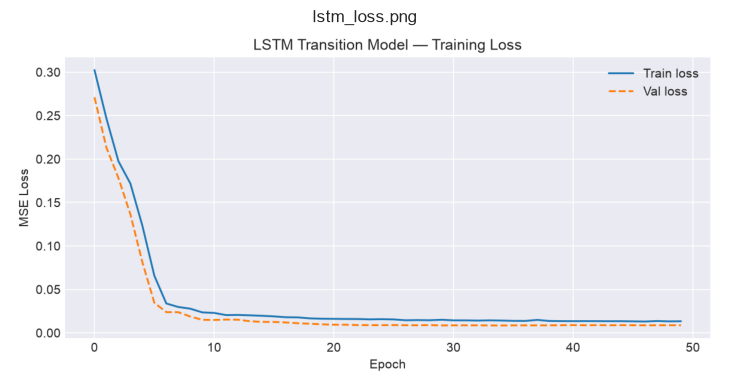

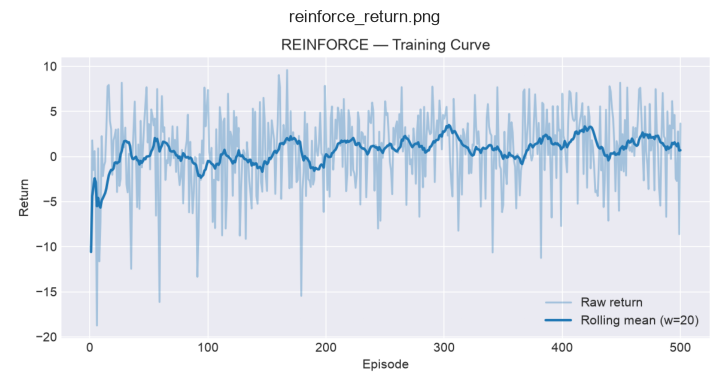

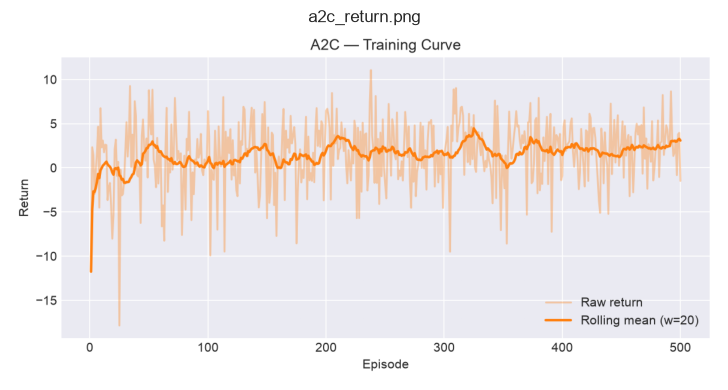

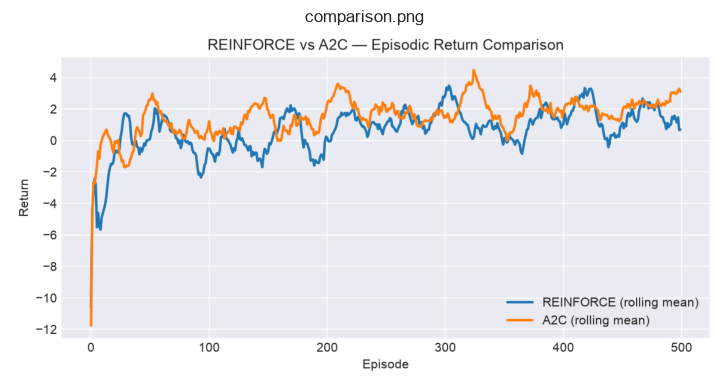

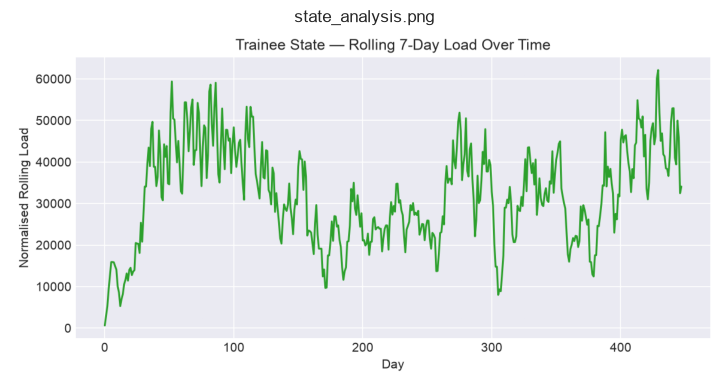

In [8]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

for p in paths:
    img = mpimg.imread(str(p))
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.imshow(img); ax.axis('off'); ax.set_title(p.name)
    plt.tight_layout(); plt.show()

## Analysis

### 1. Dataset and representation
_Was the dataset appropriate? What required feature engineering?_

### 2. LSTM model quality
_Did the LSTM produce plausible next-state predictions?_

### 3. REINFORCE versus A2C
_Convergence speed, stability, final return comparison._

### 4. Practical interpretation
_What training strategy did the policy learn?_

### 5. Limitations and improvements
_What assumptions are simplistic? How could the design be improved?_